In [495]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [496]:
cp = pd.read_csv('car_price_cleaned.csv')
cp.head()

,Unnamed: 0,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,...,cylindernumber_three,cylindernumber_twelve,cylindernumber_two,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
0,0,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,2,1,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,3,2,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,4,2,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [497]:
cp.info()

<class 'pandas.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 45 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             204 non-null    int64  
 1   symboling              204 non-null    int64  
 2   wheelbase              204 non-null    float64
 3   carlength              204 non-null    float64
 4   carwidth               204 non-null    float64
 5   carheight              204 non-null    float64
 6   curbweight             204 non-null    int64  
 7   enginesize             204 non-null    int64  
 8   boreratio              204 non-null    float64
 9   stroke                 204 non-null    float64
 10  compressionratio       204 non-null    float64
 11  horsepower             204 non-null    int64  
 12  peakrpm                204 non-null    int64  
 13  citympg                204 non-null    int64  
 14  highwaympg             204 non-null    int64  
 15  price            

In [498]:
#creating dependent and independent variable
x = cp.drop('price', axis =1)
y = cp['price']

x.head()

,Unnamed: 0,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,...,cylindernumber_three,cylindernumber_twelve,cylindernumber_two,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
0,0,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,2,1,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,3,2,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,4,2,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [499]:
#train test split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [500]:
x_train.shape

(153, 44)

In [501]:
'''#check multicolleniarity
corr = x_train.corr()
plt.figure(figsize=(20,18))
sns.heatmap(corr, annot= True)'''

'#check multicolleniarity\ncorr = x_train.corr()\nplt.figure(figsize=(20,18))\nsns.heatmap(corr, annot= True)'

In [502]:
#eliminate multicollinearity
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range (len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [503]:
corr_feature = correlation(x_train, .85)

In [504]:
x_train.drop(corr_feature, axis = 1, inplace = True)
x_test.drop(corr_feature, axis = 1, inplace = True)

In [505]:
x_train.shape

(153, 36)

In [506]:
#scalling
from sklearn.preprocessing import StandardScaler
scaller = StandardScaler()
x_train_scaled = scaller.fit_transform(x_train)
x_test_scaled = scaller.transform(x_test)

Linear Model

In [507]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(x_train_scaled, y_train)
y_pred = lin_reg.predict(x_test_scaled)
print(y_pred)

[30254.20220527 20346.45992559 11513.95460436  6630.8514492
 14182.7907953   7901.28131508 12862.97438863  6199.71140275
 18683.39747394  6302.03121169 24489.03063088  6447.34536442
 12919.1992548   5343.85687506 13659.99128987 10096.26362399
  6798.79108044  7715.31402533 13674.98257974  8445.76065137
 19709.33813438  6115.61037969  6109.28082125  2661.53241351
 37672.88176738 28843.48719194  8989.99789183  9703.47671301
 13551.61572459 15787.86020449 17301.06072081 25702.59011728
 32432.06156472 26524.75734354  6699.6683403  10138.20525293
  8083.78551741  5668.40724891 13216.68869045 13562.6294198
 13615.09036643 17248.7998864   6175.57553917  8389.28468678
  8072.45877791  7277.7395345  14605.30732617 14980.87127967
  7509.90061813 10600.16622836  6323.85153295]


Text(0, 0.5, 'predicted values')

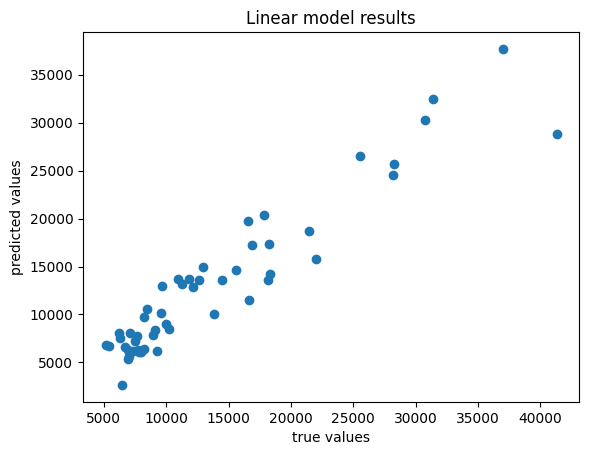

In [508]:
#plot results
plt.scatter(y_test, y_pred)
plt.title('Linear model results')
plt.xlabel('true values')
plt.ylabel('predicted values')

In [509]:
#calculate mae and R2
from sklearn.metrics import mean_absolute_error, r2_score
Lin_mae = mean_absolute_error(y_test, y_pred)
Lin_score = r2_score(y_test, y_pred)
Lin_adj_score = 1-(1-Lin_score)*(len(y_test)-1)/((len(y_test)) - x_test_scaled.shape[1]-1)

print('mean absolute error is: ', Lin_mae)
print('r2 score  is: ', Lin_score)
print('adjsuted r2 score  is: ', Lin_adj_score)

mean absolute error is:  2065.0076013422886
r2 score  is:  0.8867702268013423
adjsuted r2 score  is:  0.5956079528619369


Ridge regression

In [510]:
from sklearn.linear_model import Ridge
ridge_reg = Ridge()
ridge_reg.fit(x_train_scaled, y_train)
y_pred = ridge_reg.predict(x_test_scaled)
print(y_pred)

[29519.51784115 20185.49577784 11610.82186942  6500.86707259
 14661.14013801  7694.44091912 12987.31209104  6345.52108114
 19207.23244626  6499.16433806 24606.19892167  6593.09255192
 13224.31310502  5276.6357119  13652.39467855 10132.24811342
  5024.91346847  7540.80522558 13667.51753657  8299.65385118
 19766.38997465  6050.15037273  5995.64220497  2727.46119037
 36890.57277465 28269.0085433   9167.22129463  9824.29011494
 13876.64491223 15760.42446057 17676.1653403  25668.30760505
 31337.40279696 26574.61447119  6482.33245397 10072.86295217
  8025.70803477  5755.85811154 13136.40423238 13589.84894694
 13640.5321525  17385.02349032  6110.64180483  8488.5387068
  7801.20347983  7219.46896302 14644.03166776 15349.86016981
  7280.01321248 10706.81103187  6436.43635049]


Text(0, 0.5, 'predicted values')

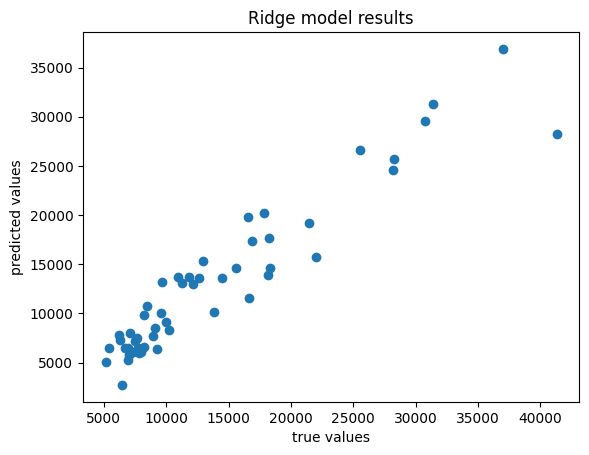

In [511]:
#plot results
plt.scatter(y_test, y_pred)
plt.title('Ridge model results')
plt.xlabel('true values')
plt.ylabel('predicted values')

In [512]:
#calculate mae and R2
from sklearn.metrics import mean_absolute_error, r2_score
ridge_mae = mean_absolute_error(y_test, y_pred)
ridge_score = r2_score(y_test, y_pred)
ridge_adj_score = 1-(1-ridge_score)*(len(y_test)-1)/((len(y_test)) - x_test_scaled.shape[1]-1)

print('mean absolute error is: ', ridge_mae)
print('r2 score  is: ', ridge_score)
print('adjsuted r2 score  is: ', ridge_adj_score)

mean absolute error is:  1996.2712228007372
r2 score  is:  0.8864556793523255
adjsuted r2 score  is:  0.5944845691154481


Lasso Regression

In [513]:
from sklearn.linear_model import Lasso
Lasso_reg = Lasso()
Lasso_reg.fit(x_train_scaled, y_train)
y_pred = Lasso_reg.predict(x_test_scaled)
print(y_pred)

[30188.18890905 20320.04472174 11522.71492517  6614.98585267
 14198.26333028  7865.6026634  12875.76731995  6233.08367923
 18740.67510734  6310.06983121 24516.19075355  6468.44237782
 12945.10670065  5345.31274264 13647.5806563  10092.9210227
  6628.87105244  7713.19241472 13662.48774331  8432.84594947
 19705.95679894  6109.82830179  6099.11268561  2672.73145329
 37573.95763026 28803.93223582  8996.73550548  9723.73322943
 13567.81179851 15796.10140782 17327.62813333 25706.69600378
 32272.95615638 26537.18878062  6664.48790238 10127.65613173
  8067.27221506  5686.10259377 13201.59643909 13577.29061813
 13629.21766005 17254.84521515  6169.4566498   8418.13709352
  8032.17186316  7269.29260419 14639.65618524 15045.00030202
  7467.30396305 10612.94553178  6349.64954683]


Text(0, 0.5, 'predicted values')

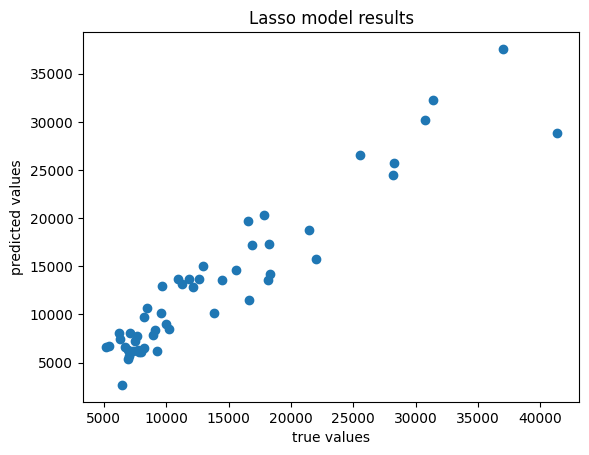

In [514]:
#plot results
plt.scatter(y_test, y_pred)
plt.title('Lasso model results')
plt.xlabel('true values')
plt.ylabel('predicted values')

In [515]:
#calculate mae and R2
from sklearn.metrics import mean_absolute_error, r2_score
Lasso_mae = mean_absolute_error(y_test, y_pred)
Lasso_score = r2_score(y_test, y_pred)
lasso_adj_score = 1-(1-Lasso_score)*(len(y_test)-1)/((len(y_test)) - x_test_scaled.shape[1]-1)


print('mean absolute error is: ', Lasso_mae)
print('r2 score  is: ', Lasso_score)
print('adjsuted r2 score  is: ', lasso_adj_score)

mean absolute error is:  2052.46496993662
r2 score  is:  0.8871576516690027
adjsuted r2 score  is:  0.5969916131035812


Decision Tree

In [516]:
from sklearn.tree import DecisionTreeRegressor
Tree_reg = DecisionTreeRegressor()
Tree_reg.fit(x_train, y_train)
y_pred = Tree_reg.predict(x_test)
print(y_pred)

[36880. 20970. 16695.  6189. 11245.  6692. 11850.  8358. 22625.  7995.
 31600.  8058.  8449.  7099. 13645.  9495.  5399.  7957. 13645.  9980.
 15998.  7609.  5118.  5572. 34028. 36880. 10898.  6989. 18620. 12764.
 11900. 31600. 45400. 31600.  5572.  8949.  7775.  7895. 11694. 14869.
 14869. 22625.  7609.  7895.  6377.  7299. 11900. 14869.  5399.  8845.
  7198.]


Text(0, 0.5, 'predicted values')

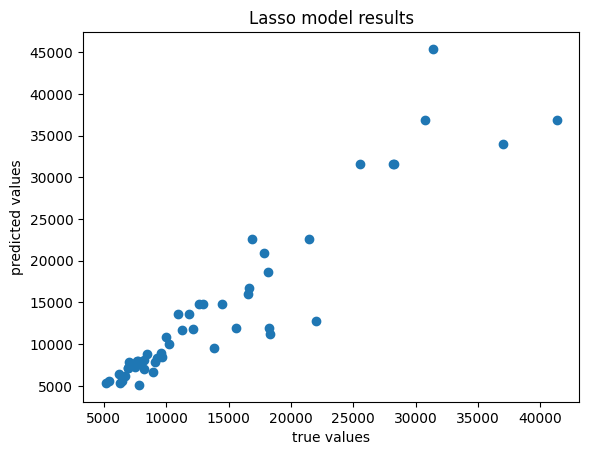

In [517]:
#plot results
plt.scatter(y_test, y_pred)
plt.title('Lasso model results')
plt.xlabel('true values')
plt.ylabel('predicted values')

In [518]:
#calculate mae and R2
from sklearn.metrics import mean_absolute_error, r2_score
tree_mae = mean_absolute_error(y_test, y_pred)
tree_score = r2_score(y_test, y_pred)
tree_adj_score = 1-(1-tree_score)*(len(y_test)-1)/((len(y_test)) - x_test.shape[1]-1)


print('mean absolute error is: ', tree_mae)
print('r2 score  is: ', tree_score)
print('adjsuted r2 score  is: ', tree_adj_score)

mean absolute error is:  2153.584960784314
r2 score  is:  0.8328406296155914
adjsuted r2 score  is:  0.403002248627112


Random forest regressor

In [519]:
from sklearn.ensemble import RandomForestRegressor
forest_reg = RandomForestRegressor()
forest_reg.fit(x_train, y_train)
y_pred = forest_reg.predict(x_test)
print(y_pred)

[36786.44  19078.39  13931.15   6189.17  11136.15   7639.875 14209.63
  8127.935 18461.3    8044.49  27381.87   7751.155  9235.3    7513.98
 13638.76  10256.66   5872.865  8305.46  13638.76  10621.12  16818.03
  7219.82   6457.86   6065.87  32647.13  36675.72  10856.83   7988.24
 17119.34  14019.7   16641.51  27403.18  37526.68  27534.2    5822.19
  9693.21   8088.335  7253.07  11623.75  14750.84  14750.84  16521.98
  7058.77   8247.45   6473.59   7078.66  14372.26  15045.75   6353.895
  9956.25   7590.02 ]


Text(0, 0.5, 'predicted values')

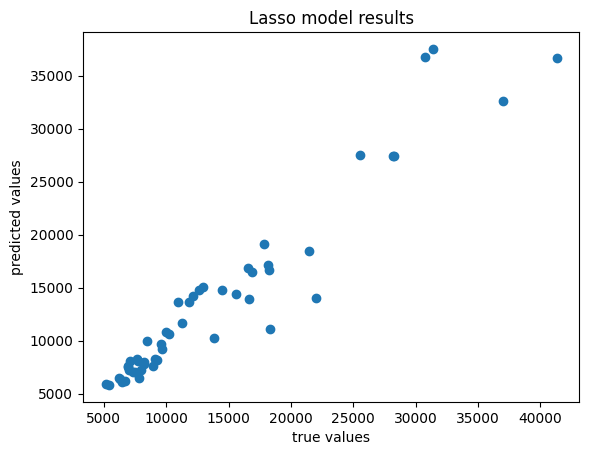

In [520]:
#plot results
plt.scatter(y_test, y_pred)
plt.title('Lasso model results')
plt.xlabel('true values')
plt.ylabel('predicted values')

In [521]:
#calculate mae and R2
from sklearn.metrics import mean_absolute_error, r2_score
forest_mae = mean_absolute_error(y_test, y_pred)
forest_score = r2_score(y_test, y_pred)
forest_adj_score = 1-(1-forest_score)*(len(y_test)-1)/((len(y_test)) - x_test.shape[1]-1)


print('mean absolute error is: ', forest_mae)
print('r2 score  is: ', forest_score)
print('adjsuted r2 score  is: ', forest_adj_score)

mean absolute error is:  1609.199078431373
r2 score  is:  0.9164219869352551
adjsuted r2 score  is:  0.7015070961973398


ElasticNet Regression

In [522]:
from sklearn.linear_model import ElasticNet
elastic_reg = ElasticNet()
elastic_reg.fit(x_train_scaled, y_train)
y_pred = elastic_reg.predict(x_test_scaled)
print(y_pred)

[25313.04655002 19885.89953269 14754.30333242  5620.94390205
 14890.03805869  6502.07130934 13553.69612678  7450.36934264
 22471.44886404  7352.063463   25113.99901219  7450.61565128
 16315.85415296  5628.60627629 13542.51258398  9528.50245541
  2596.16573797  7931.8186563  13553.75086133  9444.51570022
 19278.44077647  5953.23896432  6228.26471066  3020.08897023
 27984.41284615 24995.24526754 10734.37739886 10181.81850075
 14820.75602431 15525.19143251 18162.92793997 23236.9623926
 25137.47917623 24465.14362874  4943.59587679 10180.35233548
  8646.39807646  7662.69239787 13783.13981615 13562.70217081
 13570.8106541  16909.66980741  5998.19207371  9000.02130216
  6150.23656077  7436.6752206  15426.72542819 14978.22101379
  5794.46516188 11138.85887215  7300.47758551]


Text(0, 0.5, 'predicted values')

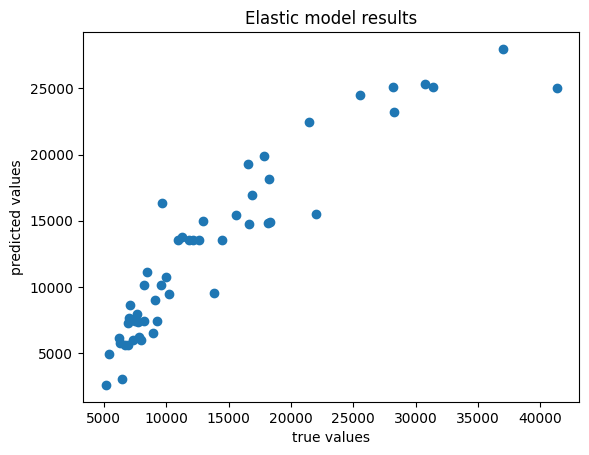

In [523]:
#plot results
plt.scatter(y_test, y_pred)
plt.title('Elastic model results')
plt.xlabel('true values')
plt.ylabel('predicted values')

In [524]:
#calculate mae and R2
from sklearn.metrics import mean_absolute_error, r2_score
elastic_mae = mean_absolute_error(y_test, y_pred)
elastic_score = r2_score(y_test, y_pred)
elastic_adj_score = 1-(1-elastic_score)*(len(y_test)-1)/((len(y_test)) - x_test_scaled.shape[1]-1)


print('mean absolute error is: ', elastic_mae)
print('r2 score  is: ', elastic_score)
print('adjsuted r2 score  is: ', elastic_adj_score)

mean absolute error is:  2352.539315164363
r2 score  is:  0.8169443108754
adjsuted r2 score  is:  0.34622968169785706


Hyperparameter tuning and cross validation

mean absolute error is:  1996.2712228002267
r2 score  is:  0.8864556793523937
adjsuted r2 score  is:  0.5944845691156917
1.0


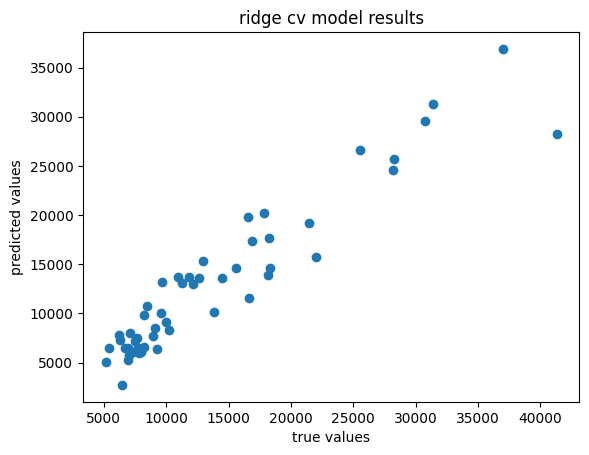

In [525]:
'''cross validation with ridge regresion'''
from sklearn.linear_model import RidgeCV
ridgecv = RidgeCV()
ridgecv.fit(x_train_scaled, y_train)
y_pred = ridgecv.predict(x_test_scaled)

plt.scatter(y_test, y_pred)
plt.title('ridge cv model results')
plt.xlabel('true values')
plt.ylabel('predicted values')

ridgecv_mae = mean_absolute_error(y_test, y_pred)
ridgecv_score = r2_score(y_test, y_pred)
ridgecv_adj_score = 1-(1-ridgecv_score)*(len(y_test)-1)/((len(y_test)) - x_test_scaled.shape[1]-1)


print('mean absolute error is: ', ridgecv_mae)
print('r2 score  is: ', ridgecv_score)
print('adjsuted r2 score  is: ', ridgecv_adj_score)

print(ridgecv.alpha_)



mean absolute error is:  1984.2287812980276
r2 score  is:  0.8882771369298541
adjsuted r2 score  is:  0.600989774749479
1.0


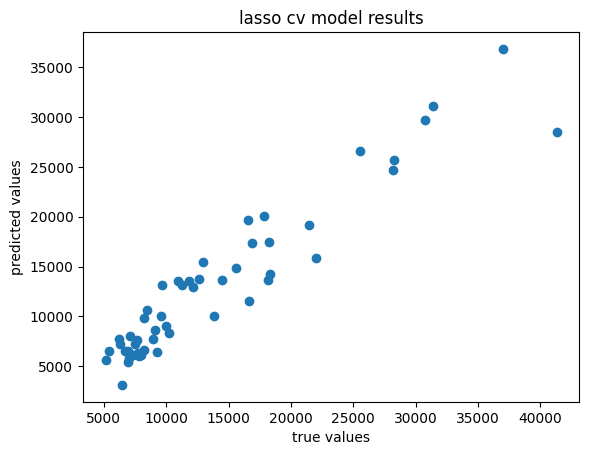

In [526]:
'''cross validation with lasso regresion'''
from sklearn.linear_model import LassoCV
lassocv = LassoCV()
lassocv.fit(x_train_scaled, y_train)
y_pred = lassocv.predict(x_test_scaled)

plt.scatter(y_test, y_pred)
plt.title('lasso cv model results')
plt.xlabel('true values')
plt.ylabel('predicted values')

lassocv_mae = mean_absolute_error(y_test, y_pred)
lassocv_score = r2_score(y_test, y_pred)
lassocv_adj_score = 1-(1-lassocv_score)*(len(y_test)-1)/((len(y_test)) - x_test_scaled.shape[1]-1)


print('mean absolute error is: ', lassocv_mae)
print('r2 score  is: ', lassocv_score)
print('adjsuted r2 score  is: ', lassocv_adj_score)

print(ridgecv.alpha_)

mean absolute error is:  1984.2287812980276
r2 score  is:  0.8882771369298541
adjsuted r2 score  is:  0.600989774749479


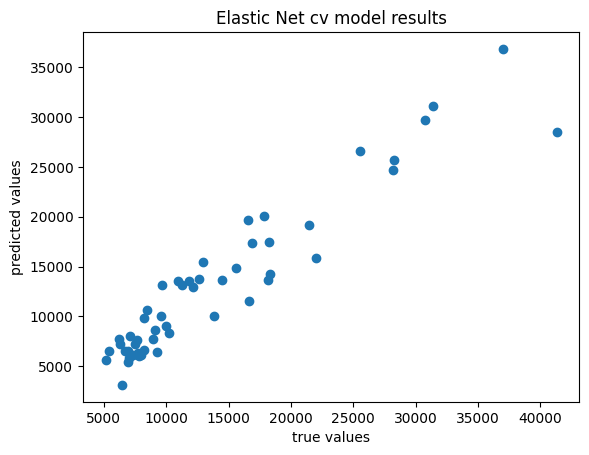

In [527]:
'''cross validation with elasticnet regresion'''
from sklearn.linear_model import ElasticNetCV
elasticcv = ElasticNetCV(l1_ratio= 1)
elasticcv.fit(x_train_scaled, y_train)
y_pred = elasticcv.predict(x_test_scaled)

plt.scatter(y_test, y_pred)
plt.title('Elastic Net cv model results')
plt.xlabel('true values')
plt.ylabel('predicted values')

elasticcv_mae = mean_absolute_error(y_test, y_pred)
elasticcv_score = r2_score(y_test, y_pred)
elasticcv_adj_score = 1-(1-elasticcv_score)*(len(y_test)-1)/((len(y_test)) - x_test_scaled.shape[1]-1)


print('mean absolute error is: ', elasticcv_mae)
print('r2 score  is: ', elasticcv_score)
print('adjsuted r2 score  is: ', elasticcv_adj_score)


Compare Final Results

In [528]:
final_results = {'Model' :[
                    'Linear Regression',
                    'Ridge Regression',
                    'Ridge CV Regression',
                    'Lasso Regression',
                    'Lasso CV Regression',
                    'ElasticNet Regression',
                    'ElasticNet CV Regression',
                    'Decision Tree Regression',
                    'Random Forest Regression'
                    ],
                "R2 Score": [
                    Lin_score,
                    ridge_score,
                    ridgecv_score,
                    Lasso_score,
                    lassocv_score,
                    elastic_score,
                    elasticcv_score,
                    tree_score,
                    forest_score
                ] ,
                'Adjusted R2 Score': [
                    Lin_adj_score,
                    ridge_adj_score,
                    ridgecv_adj_score,
                    lasso_adj_score,
                    lassocv_adj_score,
                    elastic_adj_score,
                    elasticcv_adj_score,
                    tree_adj_score,
                    forest_adj_score
                ],
                'Mean Absolute Error' : [
                    Lin_mae,
                    ridge_mae,
                    ridgecv_mae,
                    Lasso_mae,
                    lassocv_mae,
                    elastic_mae,
                    elasticcv_mae,
                    tree_mae,
                    forest_mae
                ]
                 }

comparison_df = pd.DataFrame(final_results)
print(comparison_df)

                      Model  R2 Score  Adjusted R2 Score  Mean Absolute Error
0         Linear Regression  0.886770           0.595608          2065.007601
1          Ridge Regression  0.886456           0.594485          1996.271223
2       Ridge CV Regression  0.886456           0.594485          1996.271223
3          Lasso Regression  0.887158           0.596992          2052.464970
4       Lasso CV Regression  0.888277           0.600990          1984.228781
5     ElasticNet Regression  0.816944           0.346230          2352.539315
6  ElasticNet CV Regression  0.888277           0.600990          1984.228781
7  Decision Tree Regression  0.832841           0.403002          2153.584961
8  Random Forest Regression  0.916422           0.701507          1609.199078


In [529]:
corr_with_target = cp.corr(numeric_only=True)['price'].sort_values(ascending=False)
print(corr_with_target.head(15))

price                  1.000000
enginesize             0.873658
curbweight             0.834620
horsepower             0.807376
carwidth               0.758312
carlength              0.681422
drivewheel_rwd         0.637773
wheelbase              0.576272
boreratio              0.550852
fuelsystem_mpfi        0.515142
cylindernumber_six     0.474464
enginetype_ohcv        0.385667
enginelocation_rear    0.325081
cylindernumber_five    0.249086
carbody_hardtop        0.225435
Name: price, dtype: float64
